# Decision Tree Classifier on Iris Dataset

In [25]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


In [26]:
# Load Dataset
iris = load_iris()

X = iris.data
y = iris.target

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Training Data Shape: (120, 4)
Testing Data Shape: (30, 4)


In [27]:
parameters={
    'criterion':['gini','entropy','log_loss'],
    'splitter':['best','random'],
    'max_depth':[1,2,3,4,5],
    'max_features':['auto','sqrt','log2']
}

In [28]:
from sklearn.model_selection import GridSearchCV

clf=DecisionTreeClassifier()
model=GridSearchCV(clf,param_grid=parameters,cv=5,scoring='accuracy')

model.fit(X_train,y_train)

model.best_params_

{'criterion': 'gini',
 'max_depth': 5,
 'max_features': 'log2',
 'splitter': 'random'}

In [29]:
# Create and Train Decision Tree Model
model = DecisionTreeClassifier(
    **model.best_params_
)

model.fit(X_train, y_train)


DecisionTreeClassifier(max_depth=5, max_features='log2', splitter='random')

In [30]:
# Prediction
y_pred = model.predict(X_test)


In [31]:
# Model Evaluation

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy Score:", accuracy)

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy Score: 0.9666666666666667

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      1.00      0.95         9
           2       1.00      0.91      0.95        11

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [32]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n")
print(cm)


Confusion Matrix:

[[10  0  0]
 [ 0  9  0]
 [ 0  1 10]]


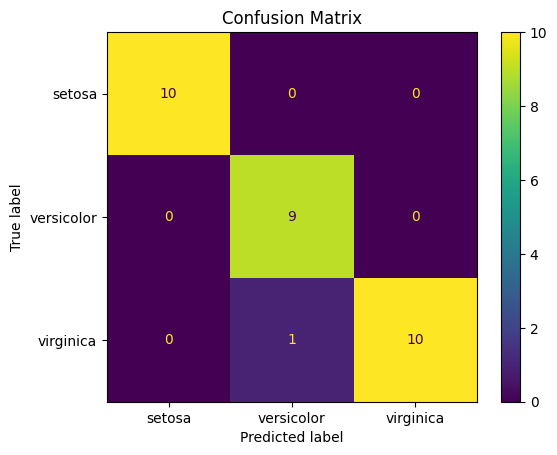

In [33]:
# Plot 1 : Confusion Matrix Display
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names).plot()
plt.title("Confusion Matrix")
plt.show()


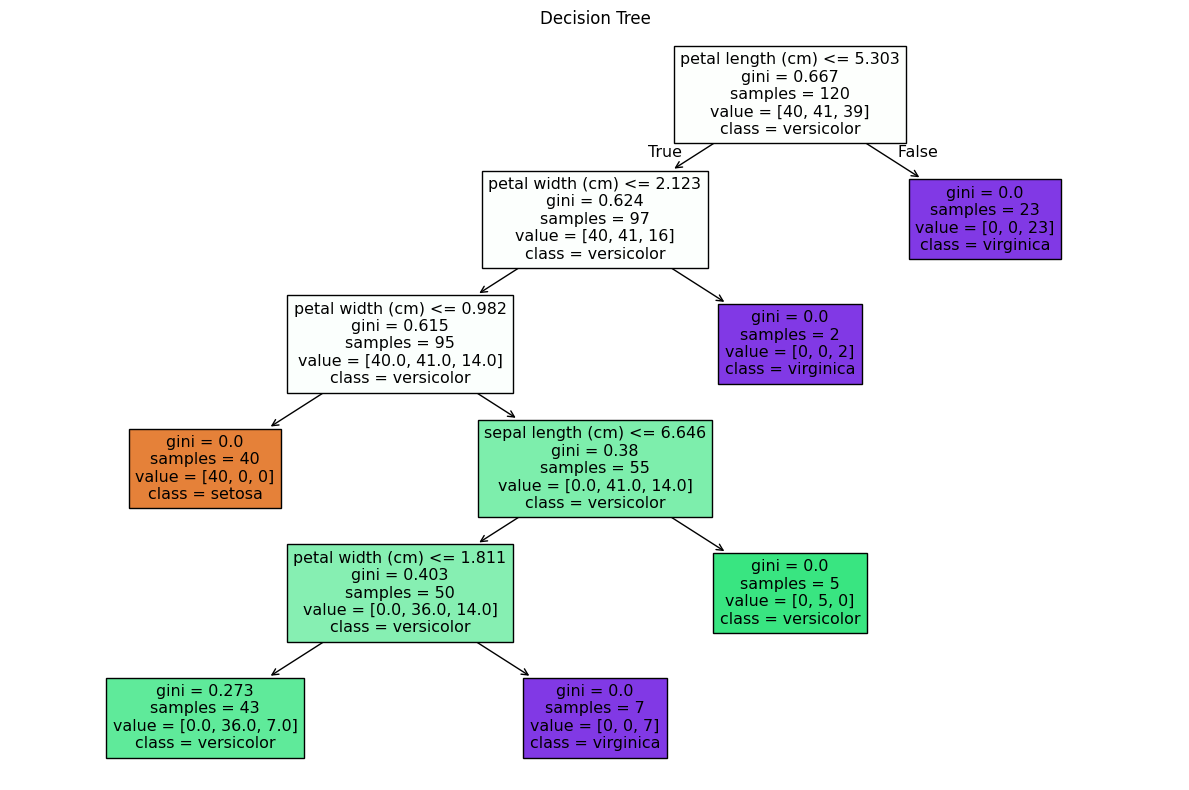

In [36]:
# Plot 2 : Decision Tree Visualization
plt.figure(figsize=(12,8))

plot_tree(
    model,
    filled=True,
    feature_names=iris.feature_names,
    class_names=iris.target_names
)

plt.title("Decision Tree")
plt.tight_layout()
plt.show()


In [35]:
# Train and Test Accuracy
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print("Train Accuracy:", train_acc)
print("Test Accuracy:", test_acc)


Train Accuracy: 0.9416666666666667
Test Accuracy: 0.9666666666666667
